In [ ]:
"""
keys= ["infer-valid-np_acc",
       "infer-valid-np_dice,",
       "infer-valid-tp_dice_0",
       "infer-valid-tp_dice_1",
       "infer-valid-tp_dice_2",
       "infer-valid-hv_mse",
       "train-loss_tp_bce",
       "train-loss_tp_dice",
       "train-loss_np_bce",
       "train-loss_np_dice",
       "train-loss-hv_mse",
       "train-loss_hv_msge",
       "train-overall_loss",
       "train-lr-net"]
"""

{'1': {'infer-valid-np_acc': 0.846741978511149, 'infer-valid-np_dice': 0.539503348776819, 'infer-valid-tp_dice_0': 0.9116441697174558, 'infer-valid-tp_dice_1': 0.18903000200147346, 'infer-valid-tp_dice_2': 0.4862502879206545, 'infer-valid-hv_mse': 0.08954389175309567, 'train-loss_tp_bce': 0.4302759201974183, 'train-loss_tp_dice': 1.4041032678393994, 'train-loss_np_bce': 0.33060853972846943, 'train-loss_np_dice': 0.5754597166854895, 'train-loss_hv_mse': 0.04125380159671689, 'train-loss_hv_msge': 0.8973954890445156, 'train-overall_loss': 3.6790967203898406, 'train-lr-net': 0.0001}, '2': {'infer-valid-np_acc': 0.8410459741172015, 'infer-valid-np_dice': 0.50186600732086, 'infer-valid-tp_dice_0': 0.9081367559141312, 'infer-valid-tp_dice_1': 0.2054737501793923, 'infer-valid-tp_dice_2': 0.45873195335644684, 'infer-valid-hv_mse': 0.08943582192804232, 'train-loss_tp_bce': 0.443167293144743, 'train-loss_tp_dice': 1.3958015782181286, 'train-loss_np_bce': 0.3403581715733081, 'train-loss_np_dice': 

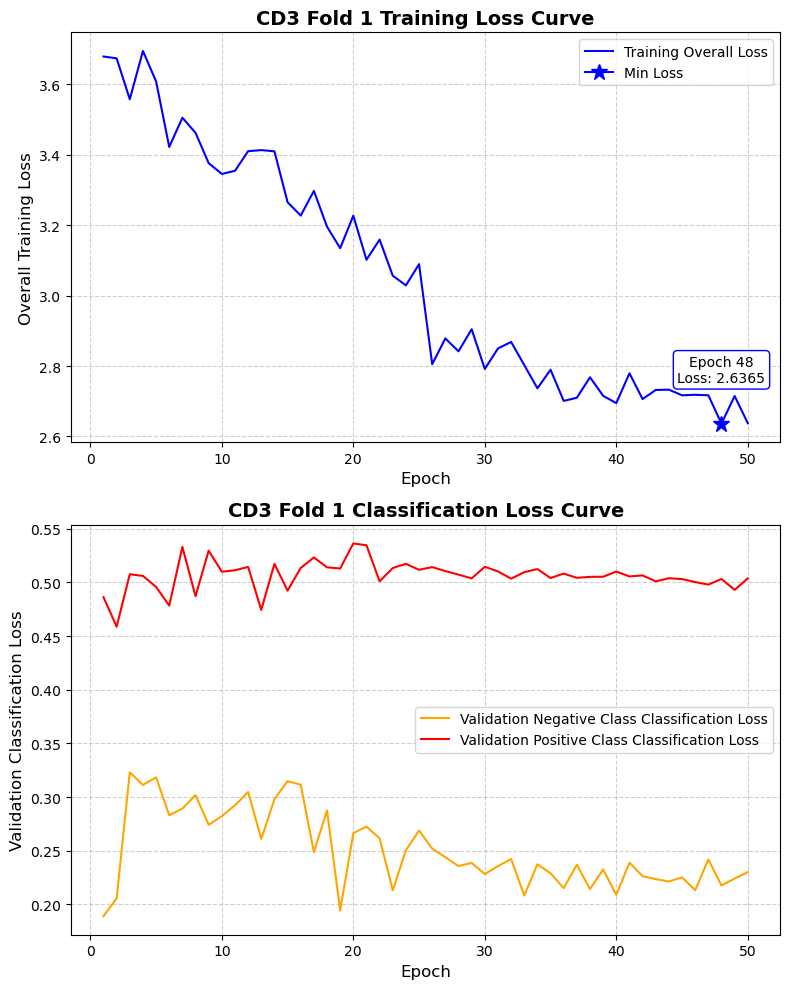

In [ ]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt

# Change directory to where the stats file is stored
os.chdir('/rds/user/mf774/hpc-work/part_II_project/in-house/train-hovernet/train-CD3/models/baseline/fold_1/model/01/')

# Load the training statistics
epoch_stats = joblib.load('stats.dat')
print(epoch_stats)

# Generate list of epoch numbers
list_of_epochs = np.arange(1, 51)

# Extract required values from epoch_stats
dice_1 = [epoch_stats[str(epoch)]["infer-valid-tp_dice_1"] for epoch in list_of_epochs]
dice_2 = [epoch_stats[str(epoch)]["infer-valid-tp_dice_2"] for epoch in list_of_epochs]
overall_loss = [epoch_stats[str(epoch)]["train-overall_loss"] for epoch in list_of_epochs]
overall_dice = [(d1 + d2) / 2 for d1, d2 in zip(dice_1, dice_2)]

# Identify epochj with minimum training loss
min_loss_train = list_of_epochs[np.argmin(overall_loss)]
best_loss_score = min(overall_loss)

# Identify epoch with minimum validation loss
min_loss_dice = list_of_epochs[np.argmin(overall_dice)]
best_dice_score = min(overall_dice)

# Create figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# Plot Training Loss
axes[0].plot(list_of_epochs, overall_loss, linestyle='-', color='b', label='Training Overall Loss')
axes[0].plot(min_loss_train, best_loss_score, marker='*', markersize=12, color='blue', label='Min Loss')

# Annotate the minimum loss point
axes[0].annotate(f'Epoch {min_loss_train}\nLoss: {best_loss_score:.4f}', 
                 (min_loss_train, best_loss_score), 
                 textcoords="offset points", 
                 xytext=(0, 30),
                 ha='center', 
                 fontsize=10, 
                 bbox=dict(boxstyle="round,pad=0.3", edgecolor="blue", facecolor="white"))

axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Overall Training Loss', fontsize=12)
axes[0].set_title('CD3 Fold 1 Training Loss Curve', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].tick_params(axis='both', labelsize=10)

# Plot Validation Type Prediction Loss
axes[1].plot(list_of_epochs, dice_1, linestyle='-', color='orange', label='Validation Negative Class Classification Loss')
axes[1].plot(list_of_epochs, dice_2, linestyle='-', color='red', label="Validation Positive Class Classification Loss")
# axes[1].plot(min_loss_dice, best_dice_score, marker='*', markersize=12, color='red', label='Min Loss')

"""
# Annotate the minimum loss point
axes[1].annotate(f'Epoch {min_loss_dice}\nLoss: {best_dice_score:.4f}', 
                 (min_loss_dice, best_dice_score), 
                 textcoords="offset points", 
                 xytext=(0, 30),
                 ha='center', 
                 fontsize=10, 
                 bbox=dict(boxstyle="round,pad=0.3", edgecolor="red", facecolor="white"))
"""

axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Validation Classification Loss', fontsize=12)
axes[1].set_title('CD3 Fold 1 Classification Loss Curve', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].tick_params(axis='both', labelsize=10)

# Adjust layout and show plot
plt.tight_layout()
plt.show()


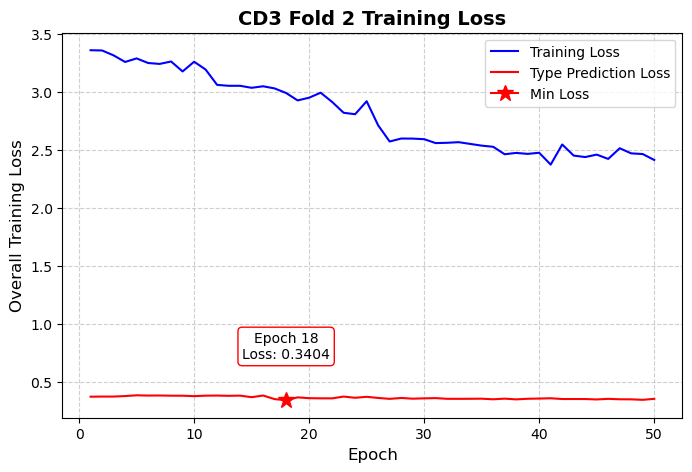

In [ ]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt

os.chdir('/rds/user/mf774/hpc-work/part_II_project/in-house/train-hovernet/train-CD3/models/baseline/fold_2/model/01/')

epoch_stats = joblib.load('stats.dat')
list_of_epochs = np.arange(1, 51)
dice_1 = [epoch_stats[str(epoch)]["infer-valid-tp_dice_1"] for epoch in list_of_epochs]
dice_2 = [epoch_stats[str(epoch)]["infer-valid-tp_dice_2"] for epoch in list_of_epochs]
overall_loss = [epoch_stats[str(epoch)]["train-overall_loss"] for epoch in list_of_epochs]
overall_dice = [(d1 + d2) / 2 for d1, d2 in zip(dice_1, dice_2)]

min_loss_epoch = list_of_epochs[np.argmin(overall_dice)]
min_loss_value = min(overall_dice)

plt.figure(figsize=(8, 5))
plt.plot(list_of_epochs, overall_loss, linestyle='-', color='b', label='Training Loss')
plt.plot(list_of_epochs, overall_dice, linestyle='-', color='r', label='Validation Type Prediction Loss')
plt.plot(min_loss_epoch, min_loss_value, marker='*', markersize=12, color='red', label='Min Loss')

plt.annotate(f'Epoch {min_loss_epoch}\nLoss: {min_loss_value:.4f}', 
             (min_loss_epoch, min_loss_value), 
             textcoords="offset points", 
             xytext=(0, 30),
             ha='center', 
             fontsize=10, 
             bbox=dict(boxstyle="round,pad=0.3", edgecolor="red", facecolor="white"))

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Overall Training Loss', fontsize=12)
plt.title('CD3 Fold 2 Training Loss', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()


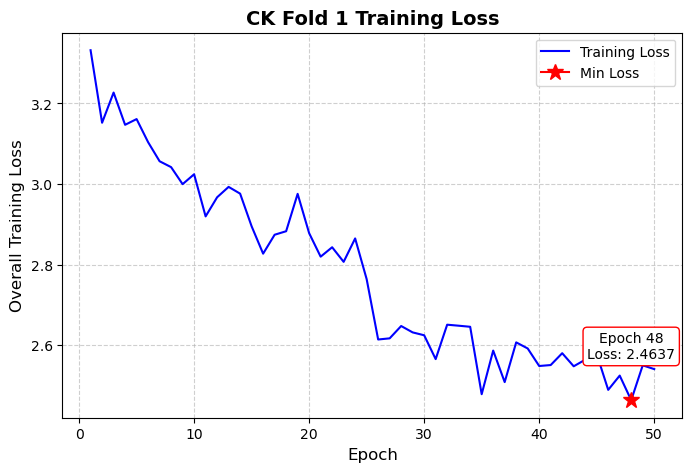

In [ ]:
os.chdir('/rds/user/mf774/hpc-work/part_II_project/in-house/train-hovernet/train-CK/models/baseline/fold_1/model/01')
epoch_stats = joblib.load('stats.dat')

# Extract data
list_of_epochs = np.arange(1, 51)
metric = [epoch_stats[str(epoch)]["train-overall_loss"] for epoch in list_of_epochs]

# Find the epoch with the smallest loss
min_loss_epoch = list_of_epochs[np.argmin(metric)]
min_loss_value = min(metric)

# Plot with improved aesthetics
plt.figure(figsize=(8, 5))
plt.plot(list_of_epochs, metric, linestyle='-', color='b', label='Training Loss')

# Highlight the minimum loss epoch with a star marker
plt.plot(min_loss_epoch, min_loss_value, marker='*', markersize=12, color='red', label='Min Loss')

# Annotate the minimum loss (placed above the point)
plt.annotate(f'Epoch {min_loss_epoch}\nLoss: {min_loss_value:.4f}', 
             (min_loss_epoch, min_loss_value), 
             textcoords="offset points", 
             xytext=(0, 30),  # Moves annotation *above* the point
             ha='center', 
             fontsize=10, 
             bbox=dict(boxstyle="round,pad=0.3", edgecolor="red", facecolor="white"))

# Formatting
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Overall Training Loss', fontsize=12)
plt.title('CK Fold 1 Training Loss', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Show the plot
plt.show()


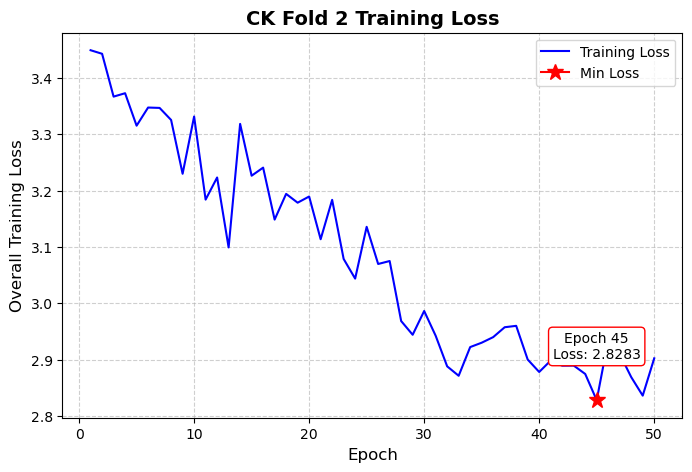

In [ ]:
os.chdir('/rds/user/mf774/hpc-work/part_II_project/in-house/train-hovernet/train-CK/models/baseline/fold_2/model/01')
epoch_first_round_stats = joblib.load('first_round_stats.dat')
epoch_second_round_stats = joblib.load('second_round_stats.dat')

correct_epoch_second_round_stats = {str(int(k) + 2): v for k, v in epoch_second_round_stats.items()}
epoch_stats = {**epoch_first_round_stats, **correct_epoch_second_round_stats}

# Extract data
list_of_epochs = np.arange(1, 51)
metric = [epoch_stats[str(epoch)]["train-overall_loss"] for epoch in list_of_epochs]

# Find the epoch with the smallest loss
min_loss_epoch = list_of_epochs[np.argmin(metric)]
min_loss_value = min(metric)

# Plot with improved aesthetics
plt.figure(figsize=(8, 5))
plt.plot(list_of_epochs, metric, linestyle='-', color='b', label='Training Loss')

# Highlight the minimum loss epoch with a star marker
plt.plot(min_loss_epoch, min_loss_value, marker='*', markersize=12, color='red', label='Min Loss')

# Annotate the minimum loss (placed above the point)
plt.annotate(f'Epoch {min_loss_epoch}\nLoss: {min_loss_value:.4f}', 
             (min_loss_epoch, min_loss_value), 
             textcoords="offset points", 
             xytext=(0, 30),  # Moves annotation *above* the point
             ha='center', 
             fontsize=10, 
             bbox=dict(boxstyle="round,pad=0.3", edgecolor="red", facecolor="white"))

# Formatting
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Overall Training Loss', fontsize=12)
plt.title('CK Fold 2 Training Loss', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Show the plot
plt.show()
